# Домашнее задание к семинару 12 (HW12)

## 1. Импорты, seed и среда

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [71]:
from pathlib import Path
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = artifacts_dir / "figures"

runs_path = artifacts_dir / "runs.csv"

## 2. Загрузка и подготовка данных

In [6]:
df = pd.read_csv("data/S12-hw-dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [7]:
print("Число наблюдений:", len(df))
print("\nДиапазон дат:")
print(df['date'].min(), "—", df['date'].max())
print("\nПропуски по колонкам:")
print(df.isna().sum())

Число наблюдений: 4320

Диапазон дат:
2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


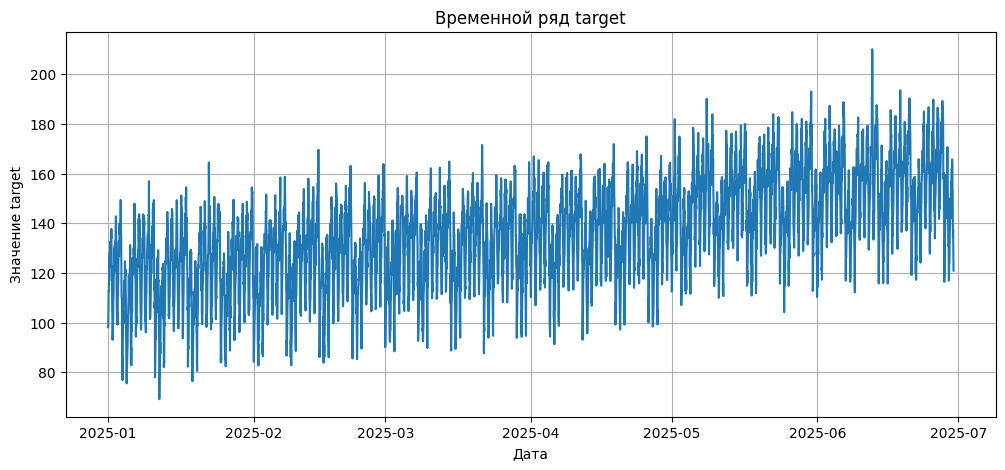

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['target'])
plt.title("Временной ряд target")
plt.xlabel("Дата")
plt.ylabel("Значение target")
plt.grid()
plt.show()

Временной ряд характеризуется восходящим трендом и наличием регулярных колебаний, указывающих на сезонность. Наблюдаются отдельные выбросы. Ряд является нестационарным, поскольку его статистические характеристики (среднее и дисперсия) изменяются во времени.


## 3. Корректный temporal split

In [9]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (3024, 2)
Validation: (648, 2)
Test: (648, 2)


In [10]:
print("\nTrain:")
print(train['date'].min(), "—", train['date'].max())

print("\nValidation:")
print(val['date'].min(), "—", val['date'].max())

print("\nTest:")
print(test['date'].min(), "—", test['date'].max())


Train:
2025-01-01 00:00:00 — 2025-05-06 23:00:00

Validation:
2025-05-07 00:00:00 — 2025-06-02 23:00:00

Test:
2025-06-03 00:00:00 — 2025-06-29 23:00:00


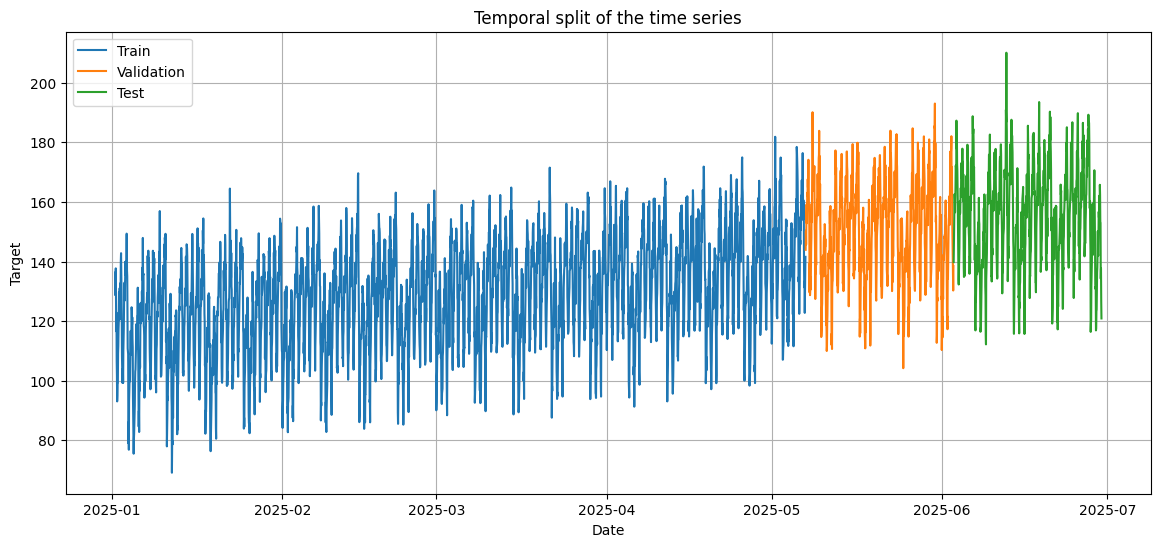

Saved: artifacts/figures/series_split.png


In [69]:
plt.figure(figsize=(14, 6))

plt.plot(train_df["date"], train_df["target"], label="Train")
plt.plot(val_df["date"], val_df["target"], label="Validation")
plt.plot(test_df["date"], test_df["target"], label="Test")

plt.title("Temporal split of the time series")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True)

series_split_path = FIGURES_DIR / "series_split.png"
plt.savefig(series_split_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", series_split_path)

Использование случайного разбиения (random split) в задачах прогнозирования временных рядов является некорректным, поскольку нарушает хронологическую структуру данных.

При случайном перемешивании наблюдений в обучающую выборку могут попасть значения из будущих периодов относительно тестовой выборки. Это приводит к утечке информации (data leakage), в результате чего модель фактически обучается на данных, которые в реальных условиях ей недоступны.

Кроме того, random split не отражает реальный сценарий применения модели, при котором прогнозирование осуществляется на основе прошлых наблюдений для предсказания будущих значений.

## 4. Признаки для baseline-моделей

In [15]:
data = df.copy()
data = data.sort_values("date").reset_index(drop=True)

# Лаговые признаки
data["lag_1"] = data["target"].shift(1)
data["lag_7"] = data["target"].shift(7)
data["lag_14"] = data["target"].shift(14)

# Скользящие статистики только по прошлым значениям
data["rolling_mean_7"] = data["target"].shift(1).rolling(window=7).mean()
data["rolling_std_7"] = data["target"].shift(1).rolling(window=7).std()

# Календарные признаки
data["day_of_week"] = data["date"].dt.dayofweek
data["day"] = data["date"].dt.day
data["month"] = data["date"].dt.month
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

data.head(15)

,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day,month,is_weekend
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,2,1,1,0
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,NaN,NaN,2,1,1,0
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,NaN,NaN,2,1,1,0
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,NaN,NaN,2,1,1,0
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,NaN,NaN,2,1,1,0
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,NaN,NaN,2,1,1,0
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,NaN,NaN,2,1,1,0
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,2,1,1,0
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,2,1,1,0
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,2,1,1,0


In [16]:
data_features = data.dropna().reset_index(drop=True)
print("Размер после генерации признаков:", data_features.shape)
data_features.head()

Размер после генерации признаков: (4306, 11)


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day,month,is_weekend
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,1,1,0
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,1,1,0
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,1,1,0
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,1,1,0
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,1,1,0


In [17]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week"
]
X = data_features[feature_cols]
y = data_features["target"]

In [18]:
from sklearn.preprocessing import StandardScaler

# temporal split
n = len(data_features)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = data_features.iloc[:train_end]
val_df = data_features.iloc[train_end:val_end]
test_df = data_features.iloc[val_end:]

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

# scaler обучаем только на train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 5. Оконное представление для GRU

In [21]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

window_size = 14
batch_size = 32

train_target = train[["target"]].values
val_target = val[["target"]].values
test_target = test[["target"]].values

target_scaler = StandardScaler()
train_target_scaled = target_scaler.fit_transform(train_target)
val_target_scaled = target_scaler.transform(val_target)
test_target_scaled = target_scaler.transform(test_target)

def make_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_target_scaled, window_size)
X_val, y_val = make_windows(val_target_scaled, window_size)
X_test, y_test = make_windows(test_target_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for batch_X, batch_y in train_loader:
    print("batch_X shape:", batch_X.shape)
    print("batch_y shape:", batch_y.shape)
    break

X_train: (3010, 14, 1) y_train: (3010, 1)
X_val: (634, 14, 1) y_val: (634, 1)
X_test: (634, 14, 1) y_test: (634, 1)
batch_X shape: torch.Size([32, 14, 1])
batch_y shape: torch.Size([32, 1])


## 6. Базовые функции обучения и оценки

In [22]:
import copy
import torch
import torch.nn as nn


In [ ]:
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)  
        out = out[:, -1, :]        
        out = self.fc(out)   
        return out

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = total_loss / len(loader.dataset)
    return epoch_loss

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    val_loss = total_loss / len(loader.dataset)
    
    all_preds = np.vstack(all_preds).ravel()
    all_targets = np.vstack(all_targets).ravel()
    
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    
    return {
        "loss": val_loss,
        "mae": mae,
        "rmse": rmse,
        "preds": all_preds,
        "targets": all_targets
    }

In [89]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    n_epochs=30
):
    history = []
    
    best_val_loss = float("inf")
    best_state = None
    best_epoch = -1
    
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"]
        }
        history.append(row)
        
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f} | "
            f"val_rmse={val_metrics['rmse']:.4f}"
        )
        best_model_path = artifacts_dir / "best_gru.pt"
        torch.save(model_r1.state_dict(), best_model_path)

        
        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
    
    # Загружаем лучшую версию модели
    model.load_state_dict(best_state)
    
    history_df = pd.DataFrame(history)
    
    print(f"\nЛучшая эпоха: {best_epoch}")
    print(f"Лучший val_loss: {best_val_loss:.4f}")
    
    return model, history_df, best_epoch

In [90]:
model = GRURegressor(
    input_size=1,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model, history_df, best_epoch = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    n_epochs=30
)

Epoch 001 | train_loss=0.4645 | val_loss=0.1990 | val_mae=0.3532 | val_rmse=0.4461
Epoch 002 | train_loss=0.1578 | val_loss=0.1774 | val_mae=0.3340 | val_rmse=0.4212
Epoch 003 | train_loss=0.1458 | val_loss=0.1683 | val_mae=0.3240 | val_rmse=0.4103
Epoch 004 | train_loss=0.1417 | val_loss=0.1651 | val_mae=0.3198 | val_rmse=0.4063
Epoch 005 | train_loss=0.1388 | val_loss=0.1663 | val_mae=0.3205 | val_rmse=0.4078
Epoch 006 | train_loss=0.1358 | val_loss=0.1713 | val_mae=0.3248 | val_rmse=0.4138
Epoch 007 | train_loss=0.1329 | val_loss=0.1783 | val_mae=0.3310 | val_rmse=0.4222
Epoch 008 | train_loss=0.1303 | val_loss=0.1837 | val_mae=0.3353 | val_rmse=0.4286
Epoch 009 | train_loss=0.1282 | val_loss=0.1850 | val_mae=0.3365 | val_rmse=0.4301
Epoch 010 | train_loss=0.1262 | val_loss=0.1825 | val_mae=0.3352 | val_rmse=0.4272
Epoch 011 | train_loss=0.1241 | val_loss=0.1786 | val_mae=0.3326 | val_rmse=0.4226
Epoch 012 | train_loss=0.1220 | val_loss=0.1744 | val_mae=0.3293 | val_rmse=0.4176
Epoc

In [29]:
history_df.head()

,epoch,train_loss,val_loss,val_mae,val_rmse
0,1,0.556848,0.246357,0.390673,0.496344
1,2,0.179409,0.184390,0.339896,0.429406
2,3,0.152051,0.176417,0.332278,0.420020
3,4,0.145908,0.170782,0.326185,0.413257
4,5,0.142605,0.168300,0.323133,0.410244


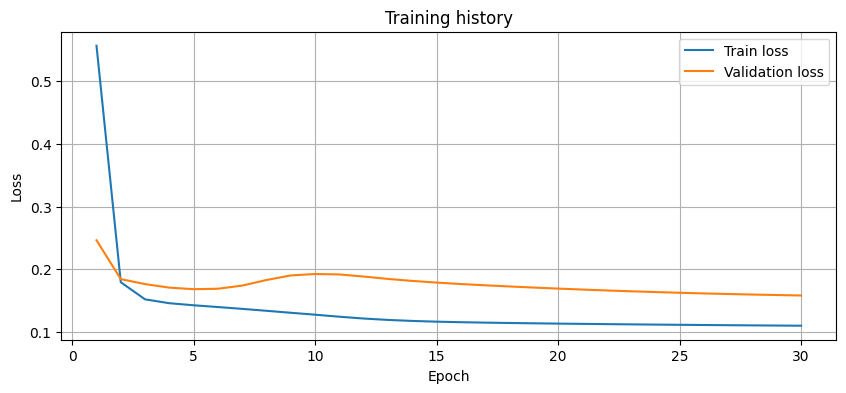

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.grid(True)
plt.legend()
plt.show()

In [31]:
val_metrics = evaluate(model, val_loader, criterion, device)

print("Validation results:")
print("Loss :", round(val_metrics["loss"], 4))
print("MAE  :", round(val_metrics["mae"], 4))
print("RMSE :", round(val_metrics["rmse"], 4))

Validation results:
Loss : 0.1583
MAE  : 0.3111
RMSE : 0.3978


In [32]:
test_metrics = evaluate(model, test_loader, criterion, device)

print("Test results:")
print("Loss :", round(test_metrics["loss"], 4))
print("MAE  :", round(test_metrics["mae"], 4))
print("RMSE :", round(test_metrics["rmse"], 4))

Test results:
Loss : 0.2075
MAE  : 0.362
RMSE : 0.4555


In [33]:
def evaluate_inverse(model, loader, criterion, device, scaler):
    model.eval()
    total_loss = 0.0
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    # Возврат в исходный масштаб
    all_preds_inv = scaler.inverse_transform(all_preds).ravel()
    all_targets_inv = scaler.inverse_transform(all_targets).ravel()
    
    mae = mean_absolute_error(all_targets_inv, all_preds_inv)
    rmse = np.sqrt(mean_squared_error(all_targets_inv, all_preds_inv))
    
    return {
        "loss_scaled": avg_loss,
        "mae": mae,
        "rmse": rmse,
        "preds": all_preds_inv,
        "targets": all_targets_inv
    }

In [34]:
val_metrics_inv = evaluate_inverse(model, val_loader, criterion, device, target_scaler)

print("Validation in original scale:")
print("MAE  :", round(val_metrics_inv["mae"], 4))
print("RMSE :", round(val_metrics_inv["rmse"], 4))

Validation in original scale:
MAE  : 5.749
RMSE : 7.3526


In [35]:
test_metrics_inv = evaluate_inverse(model, test_loader, criterion, device, target_scaler)

print("Test in original scale:")
print("MAE  :", round(test_metrics_inv["mae"], 4))
print("RMSE :", round(test_metrics_inv["rmse"], 4))

Test in original scale:
MAE  : 6.69
RMSE : 8.4181


# Эксперименты

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [37]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true), eps, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.clip(np.abs(y_true) + np.abs(y_pred), eps, None)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def calc_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred)
    }

In [39]:
RUN_COLUMNS = [
    "experiment_id",
    "task",
    "dataset",
    "seed",
    "split_summary",
    "window_size",
    "horizon",
    "model_summary",
    "features_summary",
    "scaler",
    "optimizer",
    "lr",
    "epochs_trained",
    "best_val_mae",
    "best_val_rmse",
    "best_val_mape",
    "test_mae",
    "test_rmse",
    "test_mape",
    "notes",
]

In [40]:
def append_run(run_dict, path=runs_path):
    row = {col: run_dict.get(col, None) for col in RUN_COLUMNS}
    row_df = pd.DataFrame([row])

    if path.exists():
        old_df = pd.read_csv(path)
        new_df = pd.concat([old_df, row_df], ignore_index=True)
    else:
        new_df = row_df

    new_df.to_csv(path, index=False)
    return new_df

In [41]:
DATASET_NAME = "data/S12-hw-dataset.csv"
SPLIT_SUMMARY = "temporal 70/15/15"
HORIZON = 1

B1 — naive-last

In [42]:
val_pred_b1 = val_df["lag_1"].values
val_true_b1 = val_df["target"].values

metrics_b1_val = calc_metrics(val_true_b1, val_pred_b1)
metrics_b1_val

{'mae': 6.4434055727554185,
 'rmse': np.float64(8.20353204909296),
 'mape': np.float64(4.394593960122376),
 'smape': np.float64(4.360591543836804)}

In [43]:
run_b1 = {
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "split_summary": SPLIT_SUMMARY,
    "window_size": None,
    "horizon": HORIZON,
    "model_summary": "naive-last",
    "features_summary": "last known target (lag_1)",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": metrics_b1_val["mae"],
    "best_val_rmse": metrics_b1_val["rmse"],
    "best_val_mape": metrics_b1_val["mape"],
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "baseline without training"
}

append_run(run_b1)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,None,1,naive-last,last known target (lag_1),None,None,None,None,6.443406,8.203532,4.394594,None,None,None,baseline without training


B2 — moving-average

In [44]:
val_pred_b2 = val_df["rolling_mean_7"].values
val_true_b2 = val_df["target"].values

metrics_b2_val = calc_metrics(val_true_b2, val_pred_b2)
metrics_b2_val

{'mae': 12.723717381689518,
 'rmse': np.float64(15.236325500475134),
 'mape': np.float64(8.82877937382802),
 'smape': np.float64(8.626416548455037)}

In [45]:
run_b2 = {
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "split_summary": SPLIT_SUMMARY,
    "window_size": 7,
    "horizon": HORIZON,
    "model_summary": "moving-average",
    "features_summary": "rolling_mean_7 from past values only",
    "scaler": None,
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": metrics_b2_val["mae"],
    "best_val_rmse": metrics_b2_val["rmse"],
    "best_val_mape": metrics_b2_val["mape"],
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "baseline without training"
}

append_run(run_b2)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,naive-last,last known target (lag_1),NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline without training
1,B2,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,7.0,1,moving-average,rolling_mean_7 from past values only,None,None,None,None,12.723717,15.236326,8.828779,None,None,None,baseline without training


B3 — ridge-lag-features

In [46]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [47]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week"
]

In [48]:
X_train = train_df[feature_cols]
y_train = train_df["target"]

X_val = val_df[feature_cols]
y_val = val_df["target"]

In [49]:
scaler_b3 = StandardScaler()
X_train_scaled = scaler_b3.fit_transform(X_train)
X_val_scaled = scaler_b3.transform(X_val)

model_b3 = Ridge(alpha=1.0)
model_b3.fit(X_train_scaled, y_train)

val_pred_b3 = model_b3.predict(X_val_scaled)
metrics_b3_val = calc_metrics(y_val, val_pred_b3)
metrics_b3_val

/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


{'mae': 7.171741009487226,
 'rmse': np.float64(8.723751699263929),
 'mape': np.float64(4.782421080722776),
 'smape': np.float64(4.883476822723292)}

In [50]:
run_b3 = {
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "split_summary": SPLIT_SUMMARY,
    "window_size": None,
    "horizon": HORIZON,
    "model_summary": "Ridge(alpha=1.0)",
    "features_summary": ", ".join(feature_cols),
    "scaler": "StandardScaler fitted on train only",
    "optimizer": None,
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": metrics_b3_val["mae"],
    "best_val_rmse": metrics_b3_val["rmse"],
    "best_val_mape": metrics_b3_val["mape"],
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "lag + rolling + calendar features; no future leakage"
}

append_run(run_b3)

/var/folders/k8/p2vxh73s1qj6d4fytf078ghh0000gn/T/ipykernel_90671/525038755.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_df = pd.concat([old_df, row_df], ignore_index=True)


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,naive-last,last known target (lag_1),NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline without training
1,B2,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,7.0,1,moving-average,rolling_mean_7 from past values only,NaN,NaN,NaN,NaN,12.723717,15.236326,8.828779,NaN,NaN,NaN,baseline without training
2,B3,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler fitted on train only,None,None,None,7.171741,8.723752,4.782421,None,None,None,lag + rolling + calendar features; no future l...


R1 — gru-forecast

In [51]:
model_r1 = GRURegressor(
    input_size=1,
    hidden_size=64,
    num_layers=1,
    dropout=0.0
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_r1.parameters(), lr=1e-3)

model_r1, history_r1, best_epoch_r1 = train_model(
    model=model_r1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    n_epochs=30
)

Epoch 001 | train_loss=0.4825 | val_loss=0.2018 | val_mae=0.3541 | val_rmse=0.4492
Epoch 002 | train_loss=0.1640 | val_loss=0.1743 | val_mae=0.3306 | val_rmse=0.4175
Epoch 003 | train_loss=0.1473 | val_loss=0.1691 | val_mae=0.3253 | val_rmse=0.4112
Epoch 004 | train_loss=0.1424 | val_loss=0.1682 | val_mae=0.3239 | val_rmse=0.4101
Epoch 005 | train_loss=0.1396 | val_loss=0.1716 | val_mae=0.3268 | val_rmse=0.4143
Epoch 006 | train_loss=0.1370 | val_loss=0.1802 | val_mae=0.3339 | val_rmse=0.4245
Epoch 007 | train_loss=0.1345 | val_loss=0.1910 | val_mae=0.3419 | val_rmse=0.4371
Epoch 008 | train_loss=0.1321 | val_loss=0.1996 | val_mae=0.3477 | val_rmse=0.4468
Epoch 009 | train_loss=0.1298 | val_loss=0.2022 | val_mae=0.3498 | val_rmse=0.4497
Epoch 010 | train_loss=0.1275 | val_loss=0.2003 | val_mae=0.3488 | val_rmse=0.4476
Epoch 011 | train_loss=0.1249 | val_loss=0.1971 | val_mae=0.3463 | val_rmse=0.4440
Epoch 012 | train_loss=0.1225 | val_loss=0.1928 | val_mae=0.3426 | val_rmse=0.4391
Epoc

In [65]:
import json
best_gru_config = {
    "experiment_id": "R1",
    "model_name": "GRURegressor",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "device": str(device),
    "window_size": window_size,
    "horizon": 1,
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "criterion": "MSELoss",
    "epochs_trained": int(best_epoch_r1),
    "scaler": "StandardScaler on target, fit on train only",
    "split_summary": "temporal 70/15/15"
}

config_path = "artifacts/best_gru_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

print("Saved:", config_path)

Saved: artifacts/best_gru_config.json


In [52]:
val_metrics_r1 = evaluate_inverse(
    model=model_r1,
    loader=val_loader,
    criterion=criterion,
    device=device,
    scaler=target_scaler
)

val_metrics_r1

{'loss_scaled': 0.15657509115968216,
 'mae': 5.743249416351318,
 'rmse': np.float64(7.3130670311337544),
 'preds': array([168.41428 , 163.25739 , 162.8667  , 165.49673 , 164.24316 ,
        157.01352 , 151.50333 , 144.66614 , 128.64388 , 129.95615 ,
        124.61647 , 124.57487 , 132.08833 , 135.85071 , 143.43292 ,
        149.15358 , 151.51819 , 155.25497 , 154.79533 , 158.04695 ,
        164.2099  , 170.83836 , 172.58763 , 173.48413 , 169.18521 ,
        169.57878 , 169.3844  , 162.63335 , 163.99074 , 166.63066 ,
        156.31178 , 145.81277 , 137.80682 , 126.01754 , 126.79413 ,
        128.89134 , 137.98344 , 142.76245 , 153.01575 , 156.13612 ,
        157.64511 , 158.88138 , 159.55148 , 162.9543  , 162.67801 ,
        157.012   , 159.6973  , 160.4277  , 165.96921 , 168.59871 ,
        175.63202 , 168.24022 , 170.44644 , 161.18459 , 160.27483 ,
        150.98323 , 142.78848 , 132.13672 , 131.93893 , 116.3476  ,
        111.66041 , 116.49156 , 127.07825 , 133.4343  , 140.52881 ,
  

In [53]:
run_r1 = {
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "split_summary": SPLIT_SUMMARY,
    "window_size": window_size,
    "horizon": HORIZON,
    "model_summary": "GRU(hidden_size=64, num_layers=1)",
    "features_summary": "windowed target only",
    "scaler": "StandardScaler on target, fit on train only",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": best_epoch_r1,
    "best_val_mae": val_metrics_r1["mae"],
    "best_val_rmse": val_metrics_r1["rmse"],
    "best_val_mape": mape(val_metrics_r1["targets"], val_metrics_r1["preds"]),
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": "GRU forecasting with fixed window"
}

append_run(run_r1)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,naive-last,last known target (lag_1),NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline without training
1,B2,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,7.0,1,moving-average,rolling_mean_7 from past values only,NaN,NaN,NaN,NaN,12.723717,15.236326,8.828779,NaN,NaN,NaN,baseline without training
2,B3,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler fitted on train only,NaN,NaN,NaN,7.171741,8.723752,4.782421,NaN,NaN,NaN,lag + rolling + calendar features; no future l...
3,R1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,14.0,1,"GRU(hidden_size=64, num_layers=1)",windowed target only,"StandardScaler on target, fit on train only",Adam,0.001,30.0,5.743249,7.313067,3.867472,None,None,None,GRU forecasting with fixed window


In [54]:
runs_df = pd.read_csv(runs_path)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,naive-last,last known target (lag_1),NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline without training
1,B2,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,7.0,1,moving-average,rolling_mean_7 from past values only,NaN,NaN,NaN,NaN,12.723717,15.236326,8.828779,NaN,NaN,NaN,baseline without training
2,B3,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler fitted on train only,NaN,NaN,NaN,7.171741,8.723752,4.782421,NaN,NaN,NaN,lag + rolling + calendar features; no future l...
3,R1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,14.0,1,"GRU(hidden_size=64, num_layers=1)",windowed target only,"StandardScaler on target, fit on train only",Adam,0.001,30.0,5.743249,7.313067,3.867472,NaN,NaN,NaN,GRU forecasting with fixed window


In [55]:
runs_df[["experiment_id", "model_summary", "best_val_mae", "best_val_rmse", "best_val_mape"]]

,experiment_id,model_summary,best_val_mae,best_val_rmse,best_val_mape
0,B1,naive-last,6.443406,8.203532,4.394594
1,B2,moving-average,12.723717,15.236326,8.828779
2,B3,Ridge(alpha=1.0),7.171741,8.723752,4.782421
3,R1,"GRU(hidden_size=64, num_layers=1)",5.743249,7.313067,3.867472


In [56]:
val_only = runs_df.dropna(subset=["best_val_mae"]).copy()
best_row = val_only.sort_values("best_val_mae", ascending=True).iloc[0]
best_row

experiment_id                                                R1
task                                                forecasting
dataset                                 data/S12-hw-dataset.csv
seed                                                         42
split_summary                                 temporal 70/15/15
window_size                                                14.0
horizon                                                       1
model_summary                 GRU(hidden_size=64, num_layers=1)
features_summary                           windowed target only
scaler              StandardScaler on target, fit on train only
optimizer                                                  Adam
lr                                                        0.001
epochs_trained                                             30.0
best_val_mae                                           5.743249
best_val_rmse                                          7.313067
best_val_mape                           

In [57]:
best_experiment_id = best_row["experiment_id"]
print("Best experiment by validation MAE:", best_experiment_id)

Best experiment by validation MAE: R1


In [58]:
test_metrics_r1 = evaluate_inverse(
    model=model_r1,
    loader=test_loader,
    criterion=criterion,
    device=device,
    scaler=target_scaler
)

test_metrics_best = {
    "mae": test_metrics_r1["mae"],
    "rmse": test_metrics_r1["rmse"],
    "mape": mape(test_metrics_r1["targets"], test_metrics_r1["preds"]),
    "smape": smape(test_metrics_r1["targets"], test_metrics_r1["preds"]),
}
test_metrics_best

{'mae': 6.631520748138428,
 'rmse': np.float64(8.31382293499408),
 'mape': np.float32(4.2909474),
 'smape': np.float32(4.338114)}

In [59]:
runs_df = pd.read_csv(runs_path)

mask = runs_df["experiment_id"] == best_experiment_id
runs_df.loc[mask, "test_mae"] = test_metrics_best["mae"]
runs_df.loc[mask, "test_rmse"] = test_metrics_best["rmse"]
runs_df.loc[mask, "test_mape"] = test_metrics_best["mape"]

runs_df.to_csv(runs_path, index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,naive-last,last known target (lag_1),NaN,NaN,NaN,NaN,6.443406,8.203532,4.394594,NaN,NaN,NaN,baseline without training
1,B2,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,7.0,1,moving-average,rolling_mean_7 from past values only,NaN,NaN,NaN,NaN,12.723717,15.236326,8.828779,NaN,NaN,NaN,baseline without training
2,B3,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,NaN,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler fitted on train only,NaN,NaN,NaN,7.171741,8.723752,4.782421,NaN,NaN,NaN,lag + rolling + calendar features; no future l...
3,R1,forecasting,data/S12-hw-dataset.csv,42,temporal 70/15/15,14.0,1,"GRU(hidden_size=64, num_layers=1)",windowed target only,"StandardScaler on target, fit on train only",Adam,0.001,30.0,5.743249,7.313067,3.867472,6.631521,8.313823,4.290947,GRU forecasting with fixed window


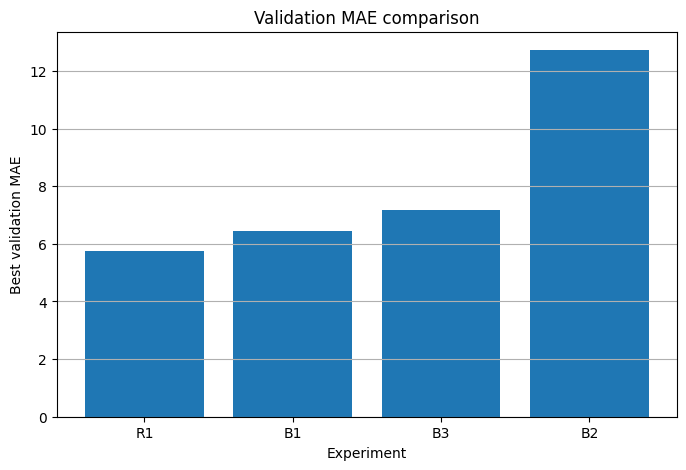

Saved: artifacts/figures/baselines_compare.png


In [72]:
runs_df = pd.read_csv(artifacts_dir / "runs.csv")

compare_df = runs_df[runs_df["experiment_id"].isin(["B1", "B2", "B3", "R1"])].copy()
compare_df = compare_df.sort_values("best_val_mae", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(compare_df["experiment_id"], compare_df["best_val_mae"])
plt.title("Validation MAE comparison")
plt.xlabel("Experiment")
plt.ylabel("Best validation MAE")
plt.grid(True, axis="y")

baselines_compare_path = FIGURES_DIR / "baselines_compare.png"
plt.savefig(baselines_compare_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", baselines_compare_path)

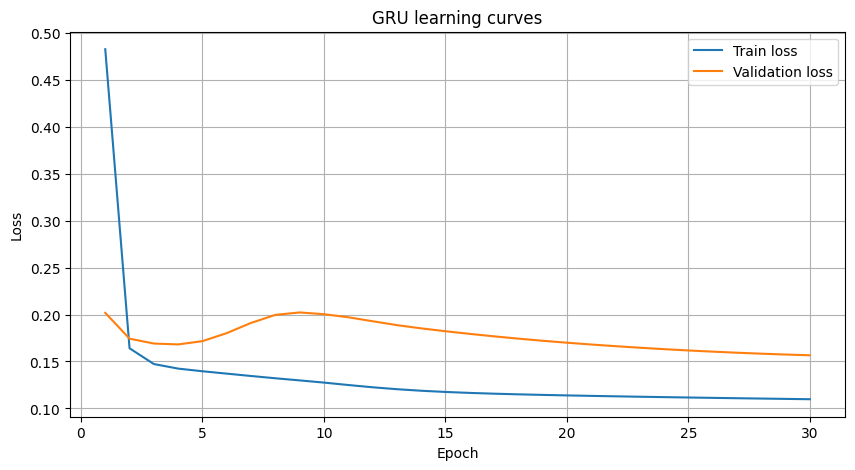

Saved: artifacts/figures/gru_learning_curves.png


In [73]:
plt.figure(figsize=(10, 5))
plt.plot(history_r1["epoch"], history_r1["train_loss"], label="Train loss")
plt.plot(history_r1["epoch"], history_r1["val_loss"], label="Validation loss")

plt.title("GRU learning curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

gru_curves_path = FIGURES_DIR / "gru_learning_curves.png"
plt.savefig(gru_curves_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", gru_curves_path)

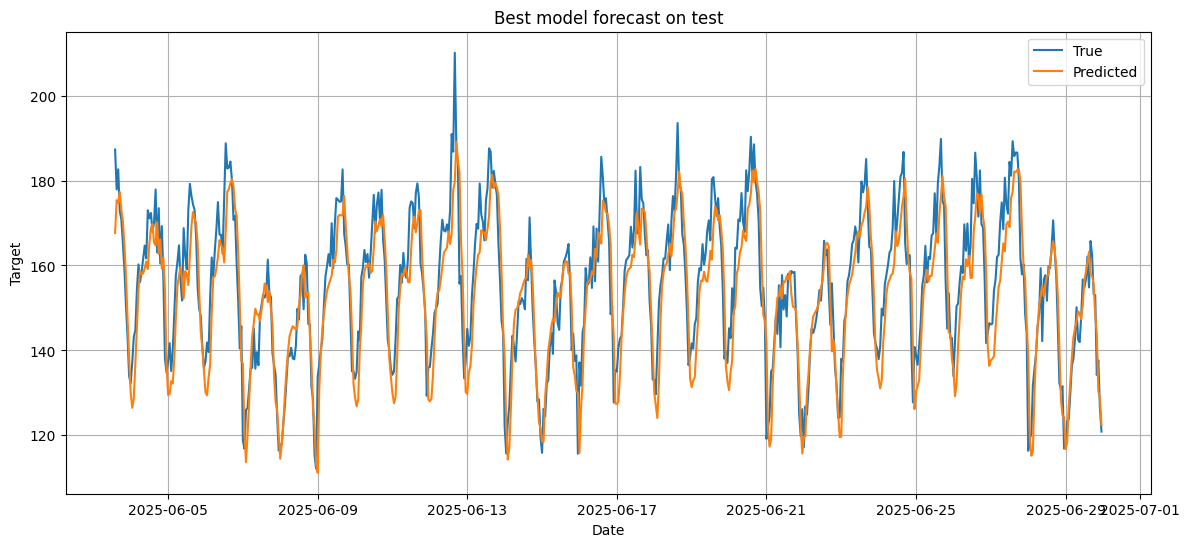

Saved: artifacts/figures/best_forecast_test.png


In [76]:
targets = np.asarray(test_metrics_r1["targets"]).ravel()
preds = np.asarray(test_metrics_r1["preds"]).ravel()

best_test_dates = test_df["date"].iloc[-len(targets):].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(best_test_dates, targets, label="True")
plt.plot(best_test_dates, preds, label="Predicted")
plt.title("Best model forecast on test")
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True)

best_forecast_test_path = FIGURES_DIR / "best_forecast_test.png"
plt.savefig(best_forecast_test_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", best_forecast_test_path)

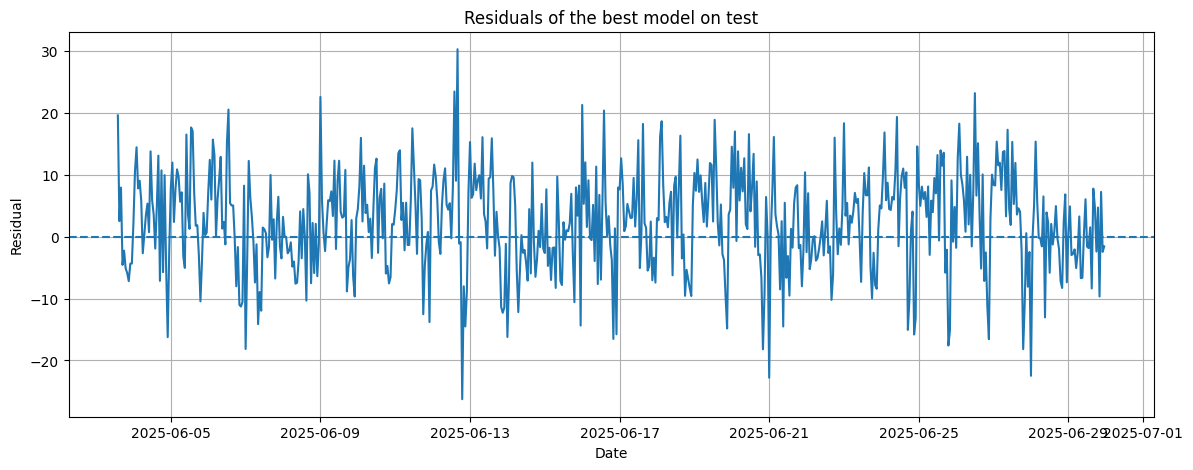

Saved: artifacts/figures/residuals_best.png


In [78]:
best_test_true = np.asarray(test_metrics_r1["targets"]).ravel()
best_test_pred = np.asarray(test_metrics_r1["preds"]).ravel()

best_residuals = best_test_true - best_test_pred

best_test_dates = test_df["date"].iloc[-len(best_test_true):].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(best_test_dates, best_residuals)
plt.axhline(0, linestyle="--")
plt.title("Residuals of the best model on test")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)

residuals_best_path = FIGURES_DIR / "residuals_best.png"
plt.savefig(residuals_best_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", residuals_best_path)

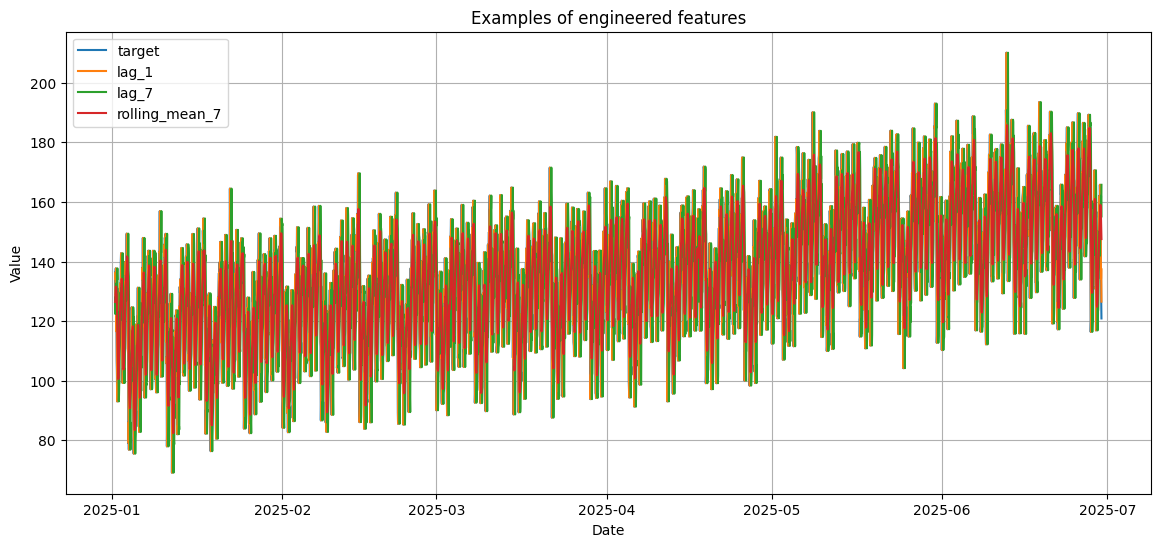

Saved: artifacts/figures/feature_examples.png


In [79]:
feature_plot_df = data_features[["date", "target", "lag_1", "lag_7", "rolling_mean_7"]].copy()

plt.figure(figsize=(14, 6))
plt.plot(feature_plot_df["date"], feature_plot_df["target"], label="target")
plt.plot(feature_plot_df["date"], feature_plot_df["lag_1"], label="lag_1")
plt.plot(feature_plot_df["date"], feature_plot_df["lag_7"], label="lag_7")
plt.plot(feature_plot_df["date"], feature_plot_df["rolling_mean_7"], label="rolling_mean_7")

plt.title("Examples of engineered features")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

feature_examples_path = FIGURES_DIR / "feature_examples.png"
plt.savefig(feature_examples_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", feature_examples_path)

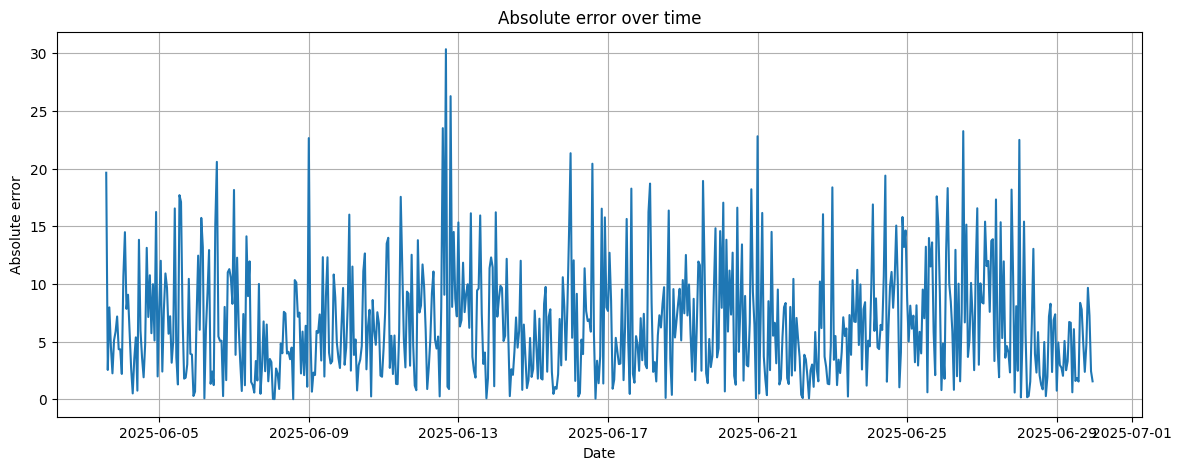

Saved: artifacts/figures/error_by_time.png


In [80]:
abs_error = np.abs(np.asarray(best_test_true) - np.asarray(best_test_pred))

plt.figure(figsize=(14, 5))
plt.plot(best_test_dates, abs_error)
plt.title("Absolute error over time")
plt.xlabel("Date")
plt.ylabel("Absolute error")
plt.grid(True)

error_by_time_path = FIGURES_DIR / "error_by_time.png"
plt.savefig(error_by_time_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", error_by_time_path)

In [91]:
for p in sorted(artifacts_dir.rglob("*")):
    print(p)

artifacts/.DS_Store
artifacts/best_gru.pt
artifacts/best_gru_config.json
artifacts/figures
artifacts/figures/.DS_Store
artifacts/figures/baselines_compare.png
artifacts/figures/best_forecast_test.png
artifacts/figures/error_by_time.png
artifacts/figures/feature_examples.png
artifacts/figures/gru_learning_curves.png
artifacts/figures/residuals_best.png
artifacts/figures/series_split.png
artifacts/runs.csv
